In [1]:
import json
import psycopg2
import pandas as pd
from datetime import datetime

import plotly.express as px
from dash import Dash, html, dcc, dash_table
from dash.dependencies import Input, Output

In [2]:
conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    port="5432"
)

cur = conn.cursor()

print("Connected successfully.")

Connected successfully.


In [3]:
JSON_FILE = "CS 590 Project Data Set #1.json"

with open(JSON_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Records found:", len(data["features"]))

Records found: 6701


In [4]:
for feature in data["features"]:

    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]

    earthquake_id = feature["id"]

    longitude = coords[0]
    latitude = coords[1]
    depth_km = coords[2]

    place = props.get("place")
    status = props.get("status")

    event_time = datetime.fromtimestamp(
        props["time"] / 1000
    )

    updated_time = datetime.fromtimestamp(
        props["updated"] / 1000
    )

    cur.execute("""
        INSERT INTO usgs_project.statuses(status_name)
        VALUES(%s)
        ON CONFLICT(status_name) DO NOTHING
    """, (status,))

    cur.execute("""
        SELECT status_id
        FROM usgs_project.statuses
        WHERE status_name = %s
    """, (status,))

    status_id = cur.fetchone()[0]

    cur.execute("""
        INSERT INTO usgs_project.locations(
            place,
            latitude,
            longitude
        )
        VALUES(%s,%s,%s)
        ON CONFLICT(place, latitude, longitude)
        DO NOTHING
    """, (place, latitude, longitude))

    cur.execute("""
        SELECT location_id
        FROM usgs_project.locations
        WHERE place=%s
          AND latitude=%s
          AND longitude=%s
    """, (place, latitude, longitude))

    location_id = cur.fetchone()[0]

    cur.execute("""
        INSERT INTO usgs_project.earthquakes (
            earthquake_id,
            location_id,
            status_id,
            magnitude,
            depth_km,
            event_time,
            updated_time,
            tsunami,
            significance,
            mag_type,
            earthquake_type,
            title,
            url
        )
        VALUES(
            %s,%s,%s,%s,%s,%s,%s,
            %s,%s,%s,%s,%s,%s
        )
        ON CONFLICT(earthquake_id)
        DO NOTHING
    """,
    (
        earthquake_id,
        location_id,
        status_id,
        props.get("mag"),
        depth_km,
        event_time,
        updated_time,
        props.get("tsunami"),
        props.get("sig"),
        props.get("magType"),
        props.get("type"),
        props.get("title"),
        props.get("url")
    ))

conn.commit()

print("ETL Complete.")

ETL Complete.


In [5]:
#Verify loaded count
query = """
SELECT COUNT(*)
FROM usgs_project.earthquakes
"""
pd.read_sql(query, conn)

/var/folders/jq/5f2hv8ss7j7cq0p1mbmqtqcc0000gn/T/ipykernel_70689/2477740258.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,count
0,6701


In [6]:
query = """
SELECT
    e.earthquake_id,
    e.magnitude,
    e.depth_km,
    e.event_time,
    e.significance,
    e.tsunami,
    l.place,
    l.latitude,
    l.longitude
FROM usgs_project.earthquakes e
JOIN usgs_project.locations l
ON e.location_id=l.location_id
"""

df = pd.read_sql(query, conn)
df["event_time"] = pd.to_datetime(df["event_time"])

df.head()

/var/folders/jq/5f2hv8ss7j7cq0p1mbmqtqcc0000gn/T/ipykernel_70689/411042233.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,earthquake_id,magnitude,depth_km,event_time,significance,tsunami,place,latitude,longitude
0,ak0254twm1q3,1.2,76.2000,2025-04-15 11:42:48.274,22,0,"30 km W of Salamatof, Alaska",60.5778,-151.8745
1,ak0254tw2r6v,1.6,68.7000,2025-04-15 10:52:47.118,39,0,"16 km SSW of Petersville, Alaska",62.3533,-150.8596
2,tx2025hjdt,2.0,6.6382,2025-04-15 10:51:49.556,62,0,"57 km S of Whites City, New Mexico",31.6590,-104.3320
3,ak0254tw0l7z,2.0,16.3000,2025-04-15 10:42:36.637,62,0,"8 km W of Point Possession, Alaska",60.9372,-150.8376
4,tx2025hjdm,2.0,6.7664,2025-04-15 10:42:13.905,62,0,"52 km SSE of Whites City, New Mexico",31.7150,-104.2680


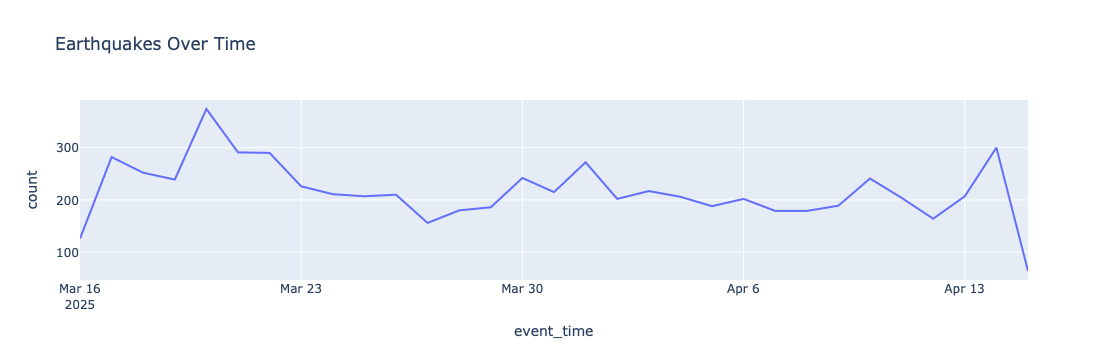

In [7]:
time_data = (
    df.groupby(
        df["event_time"].dt.date
    )
    .size()
    .reset_index(name="count")
)

fig = px.line(
    time_data,
    x="event_time",
    y="count",
    title="Earthquakes Over Time"
)

fig.show()

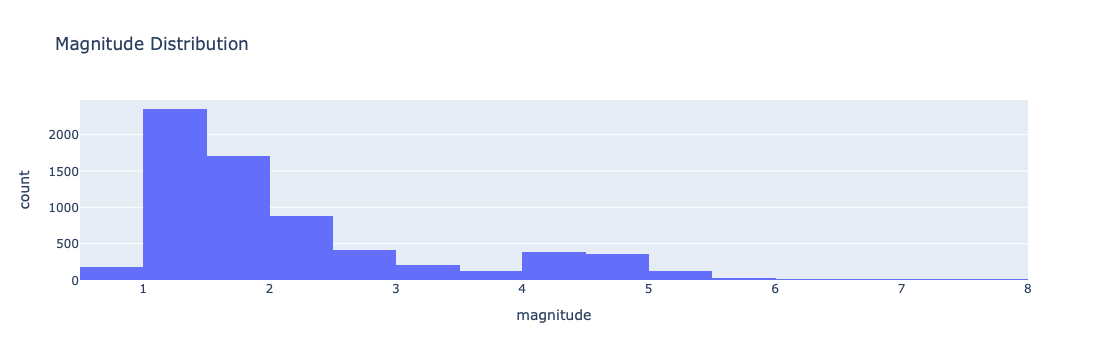

In [8]:
fig = px.histogram(
    df,
    x="magnitude",
    nbins=20,
    title="Magnitude Distribution"
)

fig.show()

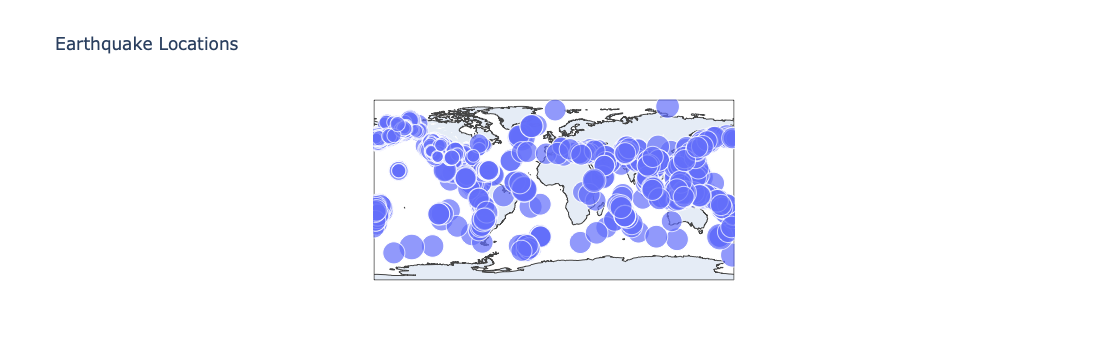

In [9]:
fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    size="magnitude",
    hover_name="place",
    title="Earthquake Locations"
)

fig.show()

In [10]:
app = Dash(__name__)

In [11]:
app.layout = html.Div(
    style={
        "fontFamily": "Arial, sans-serif",
        "backgroundColor": "#f5f6f8",
        "padding": "25px"
    },
    children=[

        html.Div(
            style={
                "backgroundColor": "white",
                "padding": "25px",
                "borderRadius": "10px",
                "boxShadow": "0 2px 8px rgba(0,0,0,0.08)"
            },
            children=[

                html.H1(
                    "USGS Earthquake Dashboard",
                    style={
                        "marginBottom": "5px"
                    }
                ),

                html.P(
                    "Interactive dashboard for exploring recent USGS earthquake activity by magnitude, time, location, and status.",
                    style={
                        "color": "#555",
                        "marginTop": "0"
                    }
                ),

                html.Hr(),

                html.Div(
                    style={
                        "marginBottom": "25px"
                    },
                    children=[
                        html.Label(
                            "Minimum Magnitude",
                            style={
                                "fontWeight": "bold"
                            }
                        ),

                        dcc.Slider(
                            id="mag-slider",
                            min=0,
                            max=8,
                            step=0.5,
                            value=2,
                            marks={
                                i: str(i)
                                for i in range(0, 9)
                            }
                        )
                    ]
                ),

                html.Div(
                    id="summary-cards",
                    style={
                        "display": "grid",
                        "gridTemplateColumns": "repeat(4, 1fr)",
                        "gap": "15px",
                        "marginBottom": "25px"
                    }
                ),

                html.Div(
                    style={
                        "display": "grid",
                        "gridTemplateColumns": "1fr 1fr",
                        "gap": "20px",
                        "marginBottom": "20px"
                    },
                    children=[
                        html.Div(
                            style={
                                "backgroundColor": "#fafafa",
                                "padding": "5px",
                                "borderRadius": "8px"
                            },
                            children=[
                                dcc.Graph(
                                    id="time-chart",
                                    style={"height": "260px"}
                                )
                            ]
                        ),

                        html.Div(
                            style={
                                "backgroundColor": "#fafafa",
                                "padding": "5px",
                                "borderRadius": "8px"
                            },
                            children=[
                                dcc.Graph(
                                    id="mag-chart",
                                    style={"height": "260px"}
                                )
                            ]
                        )
                    ]
                ),

                html.Div(
                    style={
                        "display": "grid",
                        "gridTemplateColumns": "1fr 1fr",
                        "gap": "20px",
                        "marginBottom": "20px"
                    },
                    children=[
                        html.Div(
                            style={
                                "backgroundColor": "#fafafa",
                                "padding": "5px",
                                "borderRadius": "8px"
                            },
                            children=[
                                dcc.Graph(
                                    id="map-chart",
                                    style={"height": "300px"}
                                )
                            ]
                        ),

                        html.Div(
                            style={
                                "backgroundColor": "#fafafa",
                                "padding": "5px",
                                "borderRadius": "8px"
                            },
                            children=[

                        html.Span(
                            "Earthquake Records"
                        ),

                        dash_table.DataTable(
                            id="quake-table",

                            page_size=4,

                            columns=[
                                {
                                    "name": c,
                                    "id": c
                                }
                                for c in [
                                    "magnitude",
                                    "place",
                                    "depth_km",
                                    "event_time"
                                ]
                            ],

                            style_table={
                                "overflowY": "scroll"
                            },

                            style_cell={
                                "textAlign": "left",
                                "padding": "8px",
                                "whiteSpace": "normal",
                                "height": "auto"
                            },

                            style_header={
                                "fontWeight": "bold",
                                "backgroundColor": "#e9ecef"
                            }
                        )
                    ]
                        )
                    ]
                ),
            ]
        )
    ]
)

In [12]:
@app.callback(
    Output("summary-cards", "children"),
    Output("time-chart", "figure"),
    Output("mag-chart", "figure"),
    Output("map-chart", "figure"),
    Output("quake-table", "data"),

    Input("mag-slider", "value")
)
def update_dashboard(
    minimum_magnitude
):

    filtered = df[
        df["magnitude"] >= minimum_magnitude
    ].copy()

    total_events = len(filtered)

    max_magnitude = (
        filtered["magnitude"].max()
        if total_events > 0
        else 0
    )

    avg_depth = (
        filtered["depth_km"].mean()
        if total_events > 0
        else 0
    )

    tsunami_events = (
        filtered["tsunami"].sum()
        if total_events > 0
        else 0
    )

    # SUMMARY ITEMS
    summary_values = [
        ("Total Events", f"{total_events:,}"),
        ("Largest Magnitude", f"{max_magnitude:.2f}"),
        ("Average Depth", f"{avg_depth:.2f} km"),
        ("Tsunami Flags", f"{int(tsunami_events):,}")
    ]

    summary_cards = [
        html.Div(
            style={
                "backgroundColor": "#f8f9fa",
                "padding": "8px",
                "borderRadius": "8px",
                "textAlign": "center",
                "border": "1px solid #ddd"
            },
            children=[
                html.H4(
                    label,
                    style={
                        "margin": "0",
                        "color": "#555"
                    }
                ),
                html.H2(
                    value,
                    style={
                        "margin": "4px 0 0 0",
                        "fontSize": "22px"
                    }
                )
            ]
        )
        for label, value in summary_values
    ]

    # TIME PLOT
    time_data = (
        filtered
        .groupby(
            filtered["event_time"].dt.date
        )
        .size()
        .reset_index(
            name="count"
        )
    )

    time_fig = px.line(
        time_data,
        x="event_time",
        y="count",
        title="Earthquakes Over Time"
    )
    time_fig.update_layout(margin=dict(l=20, r=20, t=40, b=20))

    # MAGNITUDE GRAPH
    mag_fig = px.histogram(
        filtered,
        x="magnitude",
        nbins=20,
        title="Magnitude Distribution"
    )
    mag_fig.update_layout(margin=dict(l=20, r=20, t=40, b=20))

    # WORLD MAP
    map_fig = px.scatter_geo(
        filtered,
        lat="latitude",
        lon="longitude",
        size="magnitude",
        hover_name="place",
        title="Earthquake Locations"
    )
    map_fig.update_layout(margin=dict(l=20, r=20, t=40, b=20))

    # TABLE DATA
    table_data = (
        filtered
        .sort_values(
            "event_time",
            ascending=False
        )
        .head(50)
        .to_dict("records")
    )

    return (
        summary_cards,
        time_fig,
        mag_fig,
        map_fig,
        table_data
    )

In [13]:
app.run(
    debug=True,
    port=8050
)